<a href="https://colab.research.google.com/github/Nikesh5005/ML_PROJ/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [3]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
df.isnull().any()

,0
Age,False
Attrition,False
BusinessTravel,False
DailyRate,False
Department,False
DistanceFromHome,False
Education,False
EducationField,False
EmployeeCount,False
EmployeeNumber,False


In [7]:
num_col=df.select_dtypes(include='number').columns.to_list()
num_col



['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [8]:
df.duplicated().any()

np.False_

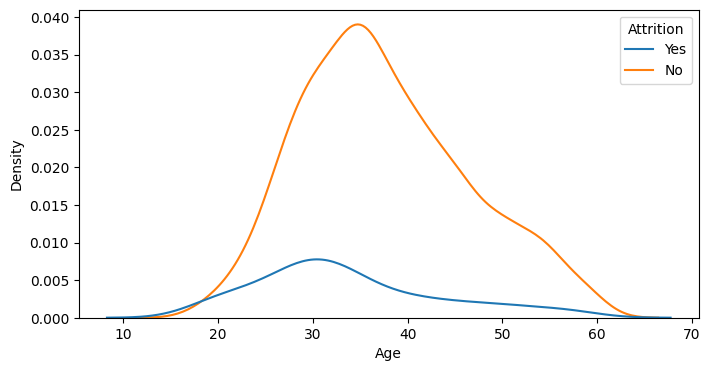

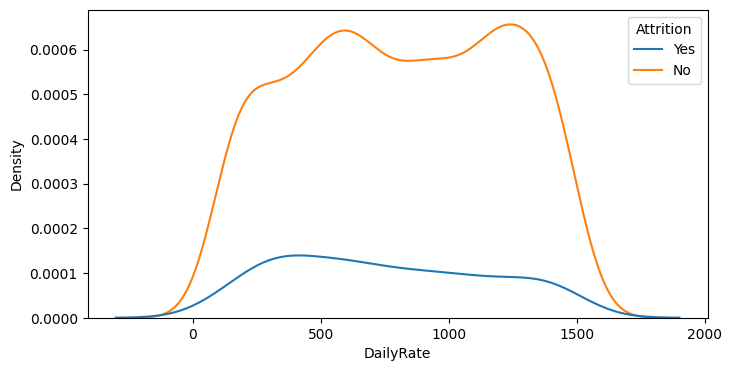

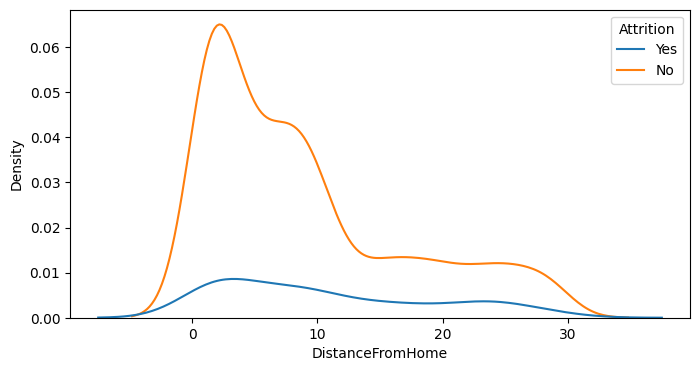

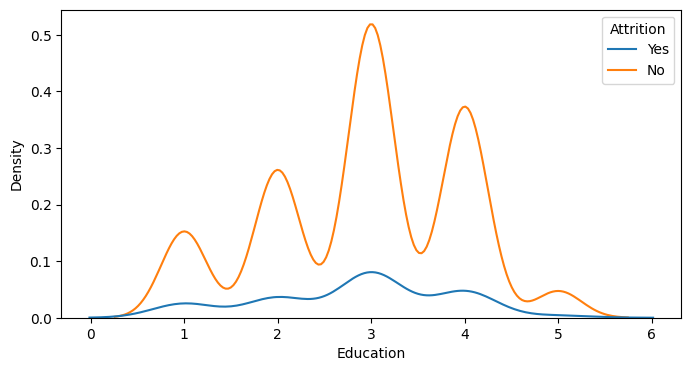

/tmp/ipykernel_1002/2484465166.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x=i,hue="Attrition")


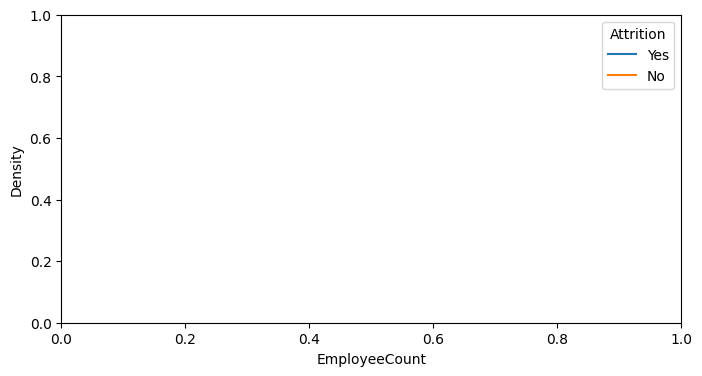

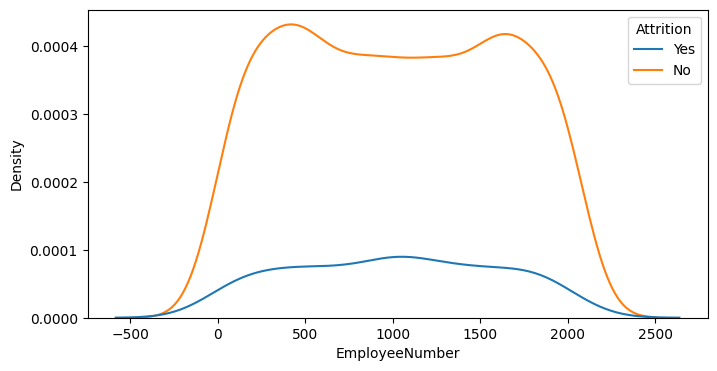

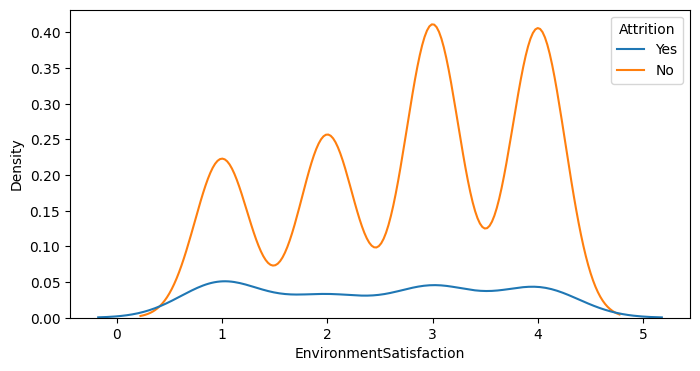

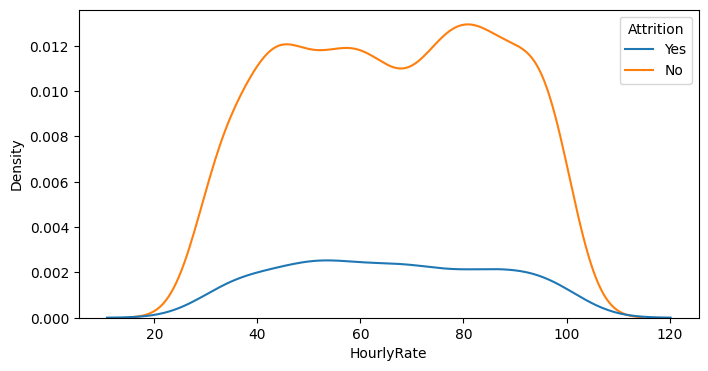

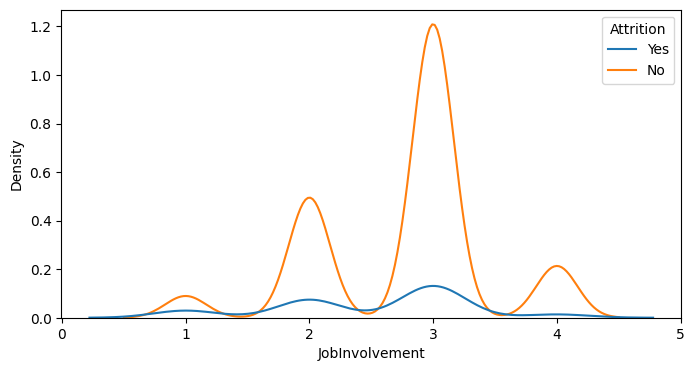

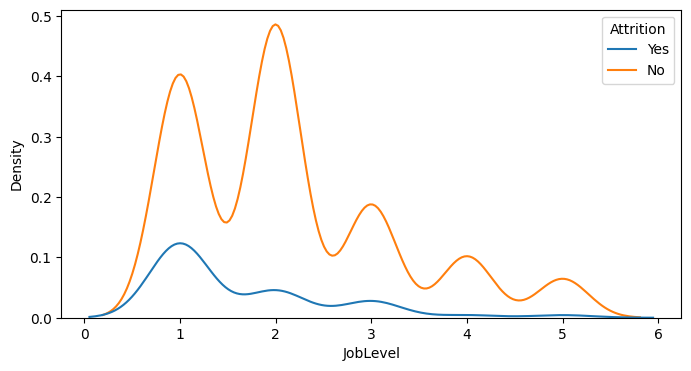

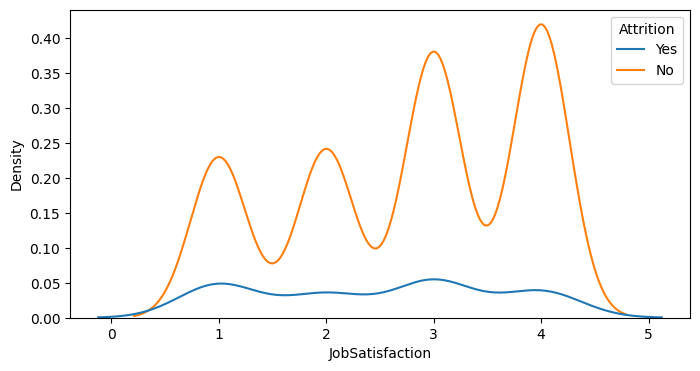

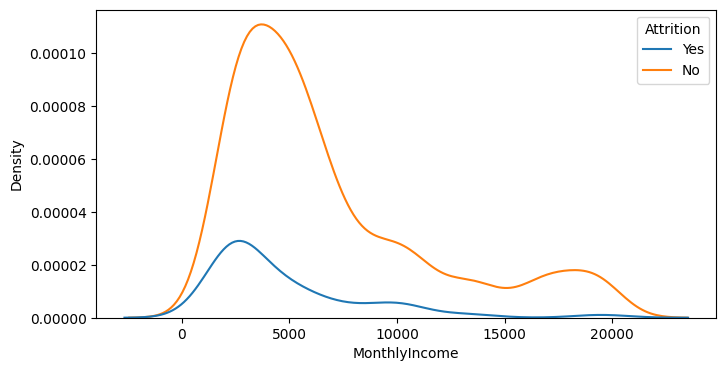

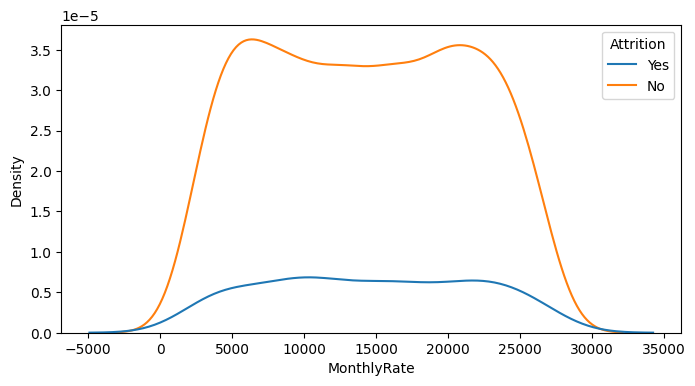

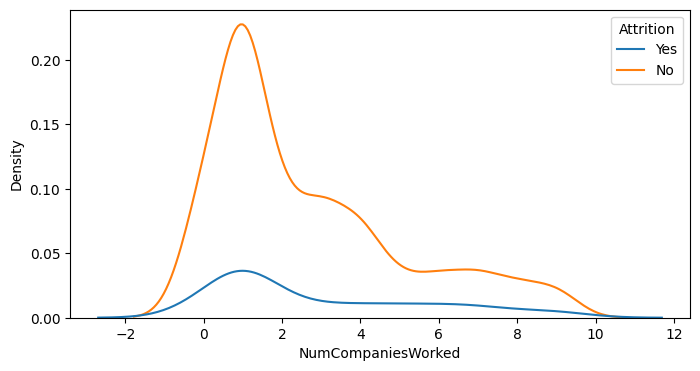

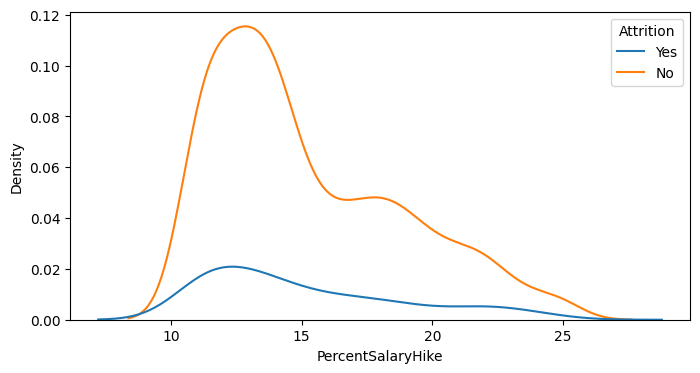

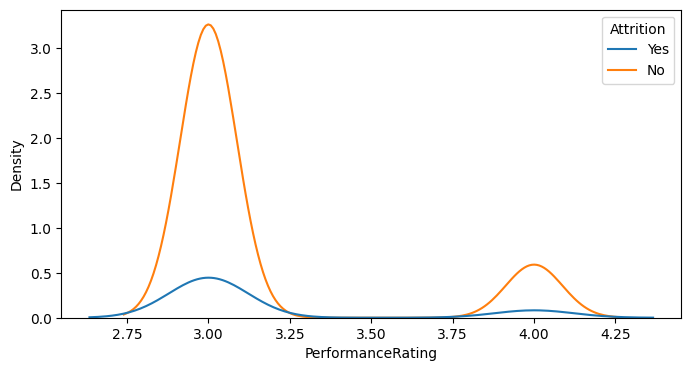

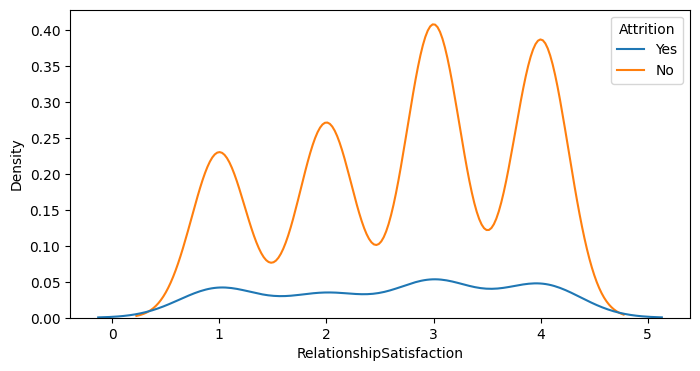

/tmp/ipykernel_1002/2484465166.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x=i,hue="Attrition")


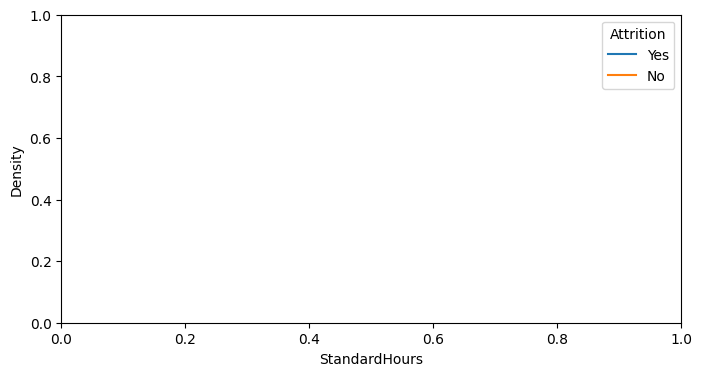

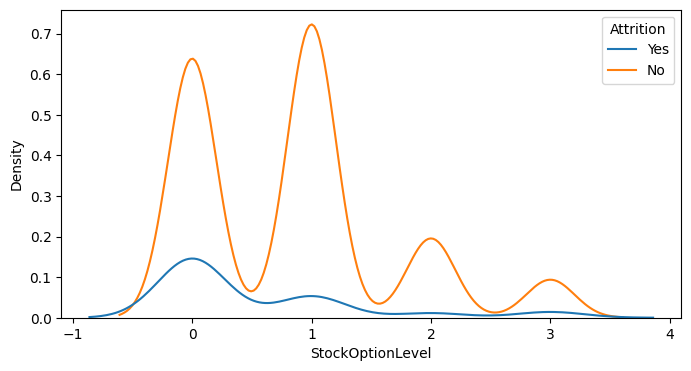

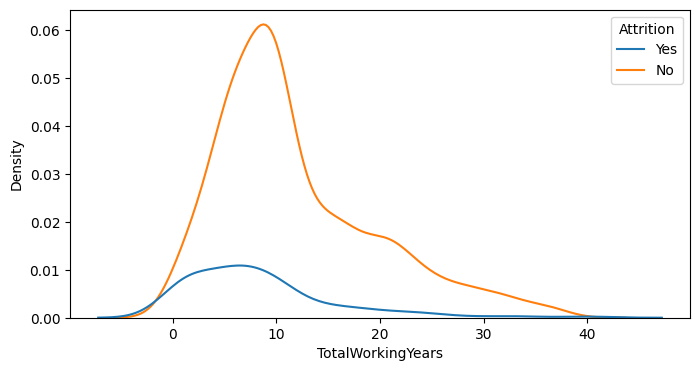

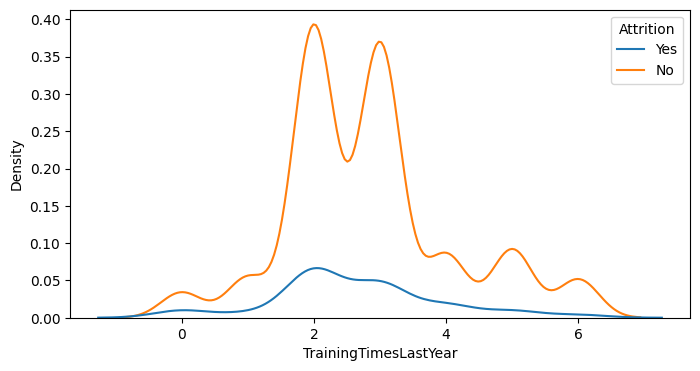

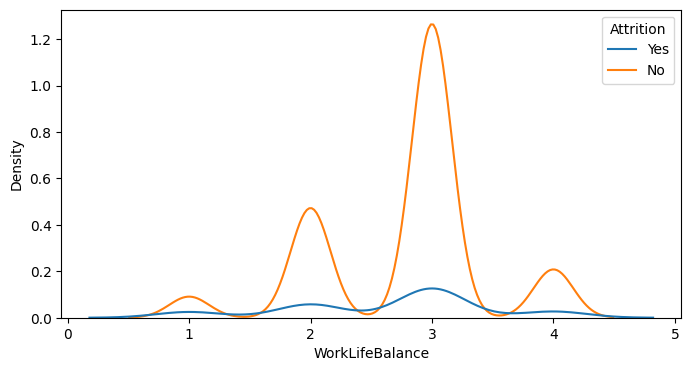

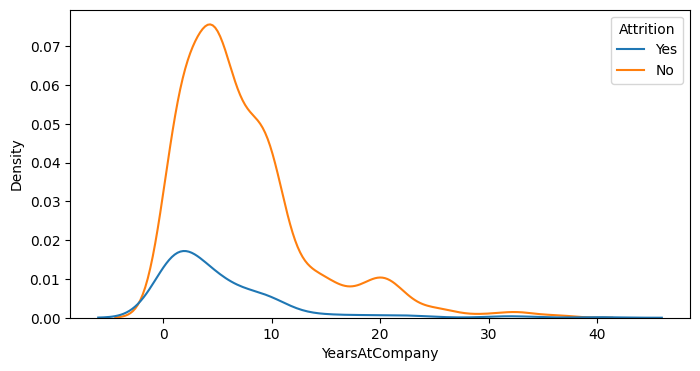

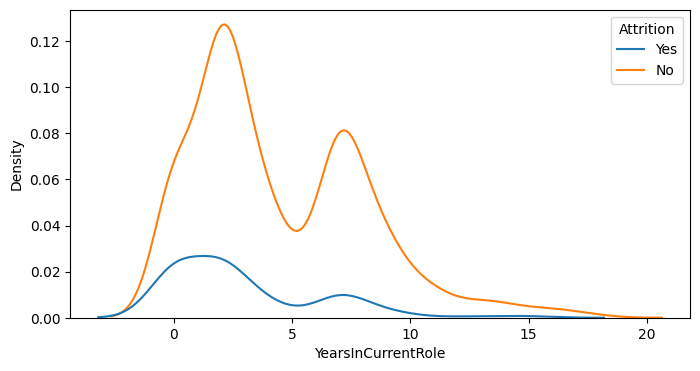

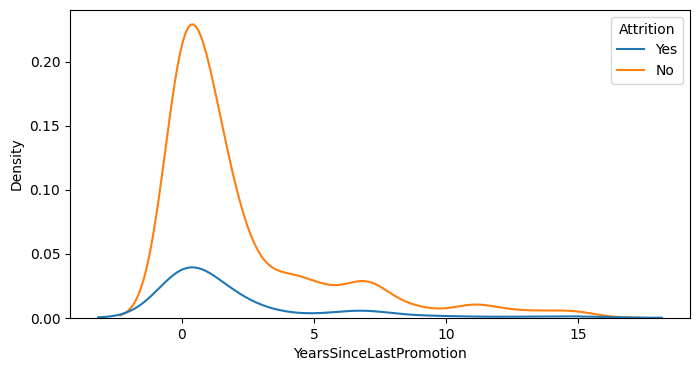

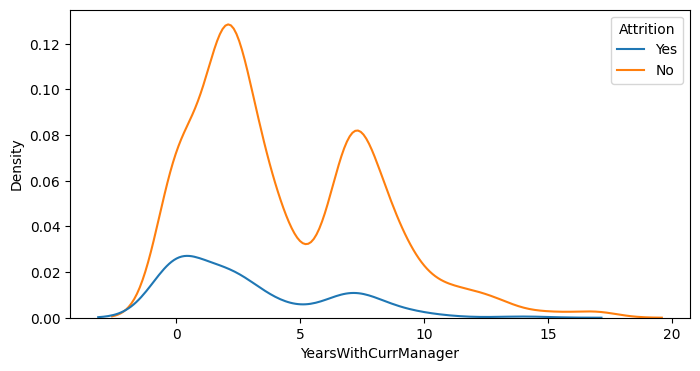

In [9]:
for i in num_col:
  plt.figure(figsize=(8,4))
  sns.kdeplot(data=df,x=i,hue="Attrition")
  plt.show()

Most numerical features show heavy overlap between the attrition classes, indicating that no single feature strongly predicts attrition. This suggests that employee attrition depends on the combined effect of multiple factors rather than one variable alone.

In [10]:
num_col=df.select_dtypes(include='object').columns.to_list()
num_col

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

<Axes: xlabel='OverTime', ylabel='count'>

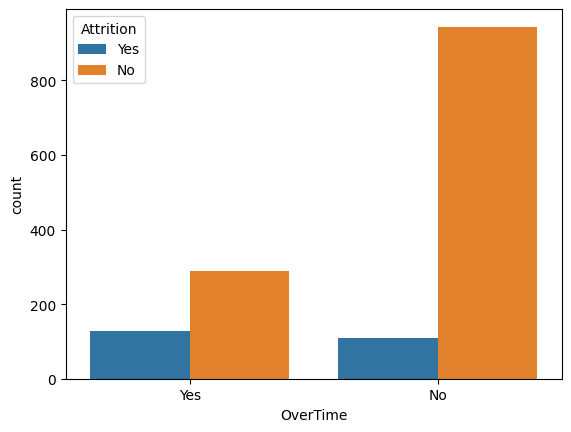

In [11]:
sns.countplot(data=df, x='OverTime', hue='Attrition')

In [12]:
output=df['Attrition']
input=df.drop(labels='Attrition',axis=1)

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    input, output, test_size=0.30, random_state=42)



ENCODING

In [14]:
input_cat_column=X_train.select_dtypes(include='object').columns.to_list()
input_num_column=X_train.select_dtypes(include='number').columns.to_list()

In [15]:
from sklearn.preprocessing import OneHotEncoder

In [16]:
encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)

In [17]:
encoder.fit(X_train[input_cat_column])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [18]:
encoder.categories_

[array(['Non-Travel', 'Travel_Frequently', 'Travel_Rarely'], dtype=object),
 array(['Human Resources', 'Research & Development', 'Sales'], dtype=object),
 array(['Human Resources', 'Life Sciences', 'Marketing', 'Medical',
        'Other', 'Technical Degree'], dtype=object),
 array(['Female', 'Male'], dtype=object),
 array(['Healthcare Representative', 'Human Resources',
        'Laboratory Technician', 'Manager', 'Manufacturing Director',
        'Research Director', 'Research Scientist', 'Sales Executive',
        'Sales Representative'], dtype=object),
 array(['Divorced', 'Married', 'Single'], dtype=object),
 array(['Y'], dtype=object),
 array(['No', 'Yes'], dtype=object)]

In [19]:
encoded_col=list(encoder.get_feature_names_out(input_cat_column))
encoded_col

['BusinessTravel_Non-Travel',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'Department_Human Resources',
 'Department_Research & Development',
 'Department_Sales',
 'EducationField_Human Resources',
 'EducationField_Life Sciences',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree',
 'Gender_Female',
 'Gender_Male',
 'JobRole_Healthcare Representative',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Manager',
 'JobRole_Manufacturing Director',
 'JobRole_Research Director',
 'JobRole_Research Scientist',
 'JobRole_Sales Executive',
 'JobRole_Sales Representative',
 'MaritalStatus_Divorced',
 'MaritalStatus_Married',
 'MaritalStatus_Single',
 'Over18_Y',
 'OverTime_No',
 'OverTime_Yes']

In [21]:
X_train_encoded=pd.DataFrame(encoder.transform(X_train[input_cat_column]),columns=encoded_col,index=X_train.index)
X_test_encoded=pd.DataFrame(encoder.transform(X_test[input_cat_column]),columns=encoded_col,index=X_test.index)

In [25]:
#X_test=pd.concat([X_test,X_test_encoded],axis=1)
#X_train=pd.concat([X_train,X_train_encoded],axis=1)

In [26]:
X_test

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
1041,28,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
184,53,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1222,24,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
67,45,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
220,36,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1047,33,Travel_Frequently,430,Sales,7,3,Medical,1,1477,4,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
331,27,Non-Travel,210,Sales,1,1,Marketing,1,449,3,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
323,28,Travel_Rarely,1157,Research & Development,2,4,Medical,1,440,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
654,39,Travel_Rarely,1383,Human Resources,2,3,Life Sciences,1,909,4,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
